#1. Data Understanding
##Bitcoin Sentiment Dataset
*  Date
*  Classification (Fear, Extreme Fear, Neutral, Greed, Extreme Greed)

##Hyperliquid Dataset

*   Account
*  Symbol
*   Side (Buy/Sell)
*   Size
*   Execution Price
*   Leverage
*   ClosedPnL
*   Time

##Objective
Determine how market sentiment affects:


*   Trader profitability
*   Win rate
*   Risk-taking behavior
*   Position sizing
*   Leverage usage
*   Trading activity













#2. Data Cleaning

In [2]:
import pandas as pd
import numpy as np

sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.normalize()

merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(merged.isnull().sum())
print(merged.head())

print("\nSentiment Counts:")
print(merged['classification'].value_counts(dropna=False))

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
date                0
classification      6
dtype: int64
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   


#3. Sentiment Distribution

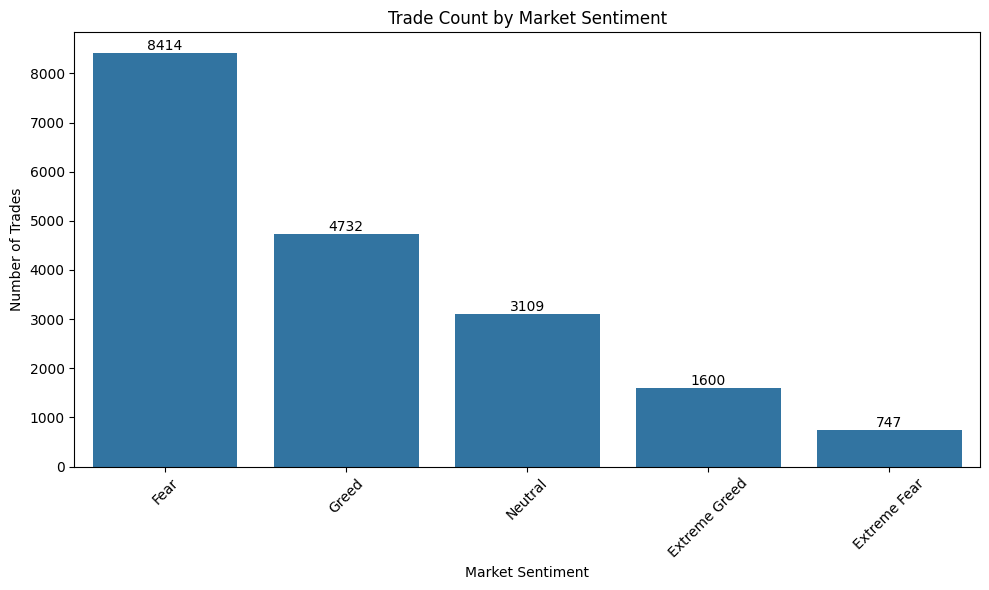

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

plot_data = merged.dropna(subset=['classification']).copy()

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=plot_data,
    x='classification',
    order=plot_data['classification'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Trade Count by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##Insight

-Most trades occur during Fear.

-Traders are more active when uncertainty is high.

#4.Total Realized Profit by Market Sentiment

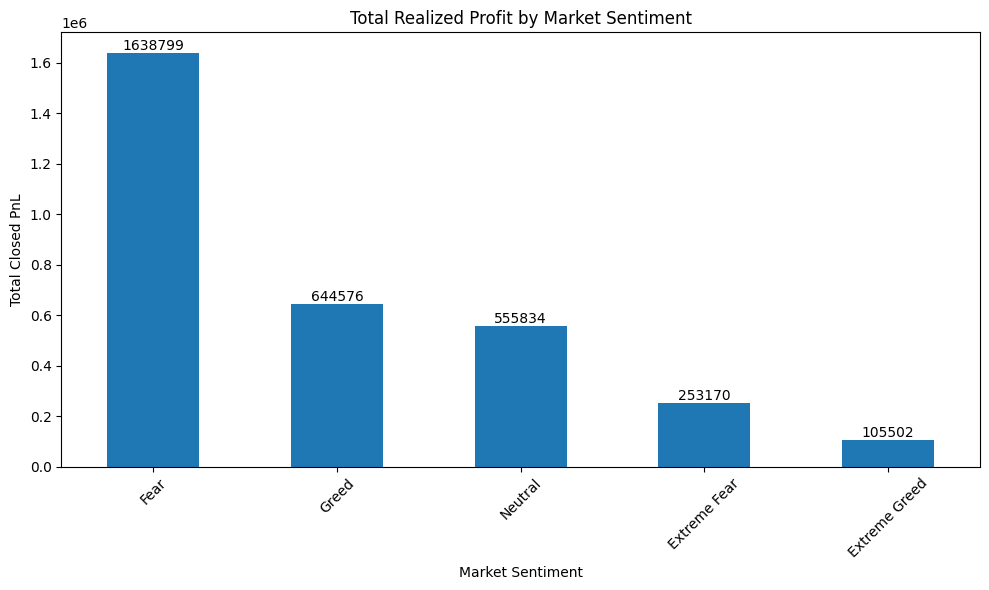

In [4]:
import matplotlib.pyplot as plt

pnl_sentiment = (
    merged.groupby('classification')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = pnl_sentiment.plot(
    kind='bar',
    rot=45
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Total Realized Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Closed PnL")

plt.tight_layout()
plt.show()

#5.Average Profit per Trade by Market Sentiment

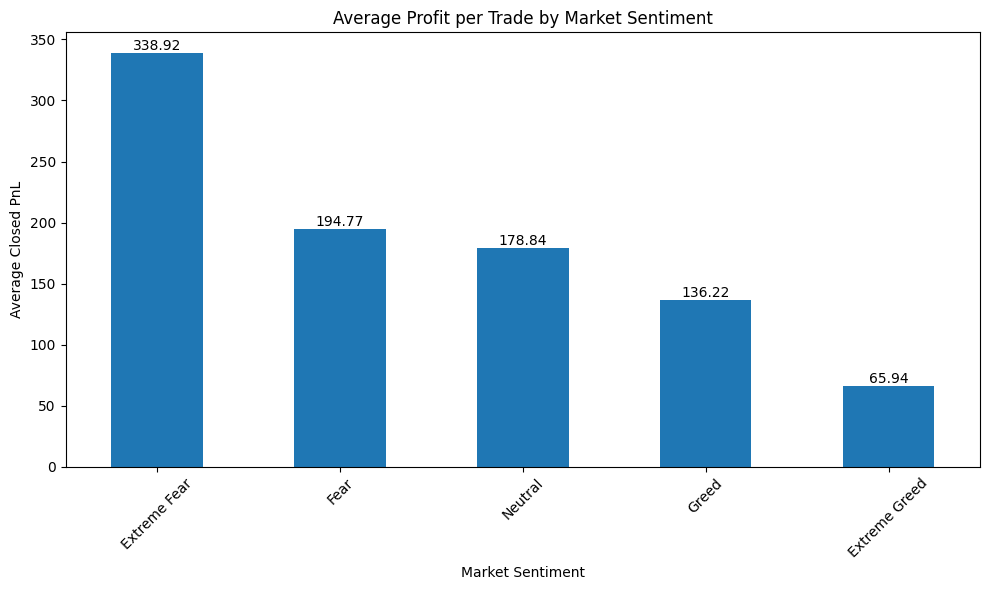

In [5]:
import matplotlib.pyplot as plt

avg_pnl = (
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = avg_pnl.plot(
    kind='bar',
    rot=45
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title("Average Profit per Trade by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()

## Insights:
-The sentiment category with the highest bar generates the greatest average profit per trade.

-A higher average PnL indicates that traders are extracting more value from each trade in that market regime.

-If Greed ranks highest, it suggests trend-following strategies perform well during bullish conditions.

-If Fear ranks highest, it indicates traders are successfully capitalizing on market overreactions and rebounds.

-If Extreme Greed shows lower average PnL than Greed, it may indicate diminishing profit opportunities as markets become overheated.

-Neutral sentiment often produces lower average profits because markets lack strong directional movement.

#6.Win Rate by Market Sentiment

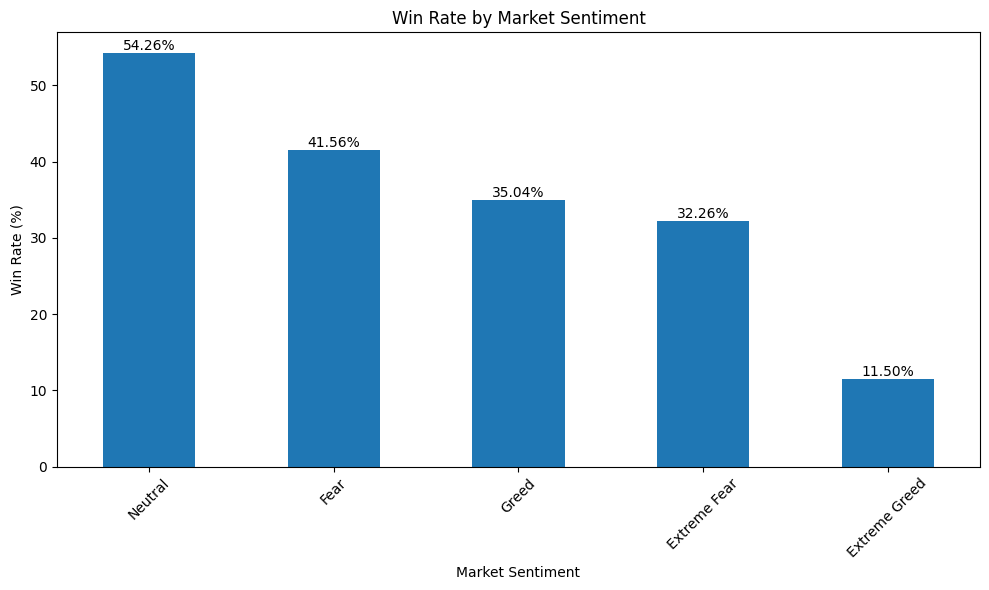

In [6]:
import matplotlib.pyplot as plt

merged['win'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['win']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = win_rate.plot(
    kind='bar',
    rot=45
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.tight_layout()
plt.show()

##Insight
-A higher win rate indicates a larger proportion of trades closed with profit.

-Sentiments with the highest win rates represent environments where traders make profitable decisions more frequently.

-If Extreme Greed shows the highest win rate, traders may be benefiting from strong bullish momentum.

-If Fear has a lower win rate but high total profits, it suggests fewer winning trades but larger gains on successful trades.

-A high win rate does not necessarily imply maximum profitability; profit size matters too.

##Business Interpretation

-This metric evaluates the consistency of trader performance under different market conditions.

-High win-rate environments are generally more predictable.

-Low win-rate environments may still be attractive if winning trades generate significantly larger profits.

-Combining win rate with Average PnL and Total PnL provides a more complete picture of trading effectiveness.

#7.Profit Distribution and Risk Analysis by Market Sentiment

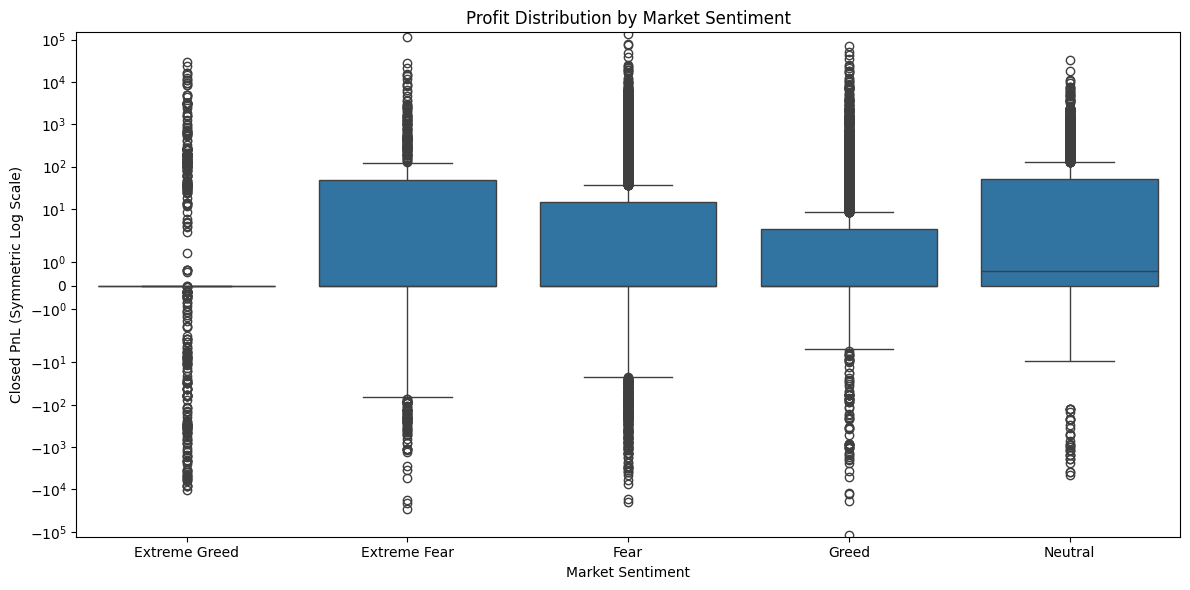

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.yscale('symlog')

plt.title("Profit Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (Symmetric Log Scale)")

plt.tight_layout()
plt.show()

##Insights
-Wider boxplots indicate higher volatility in trader performance, while narrower boxplots suggest more stable and consistent outcomes.

-Fear and Extreme Fear periods often show larger spreads in PnL, indicating greater uncertainty and larger profit/loss swings.

-Extreme Greed typically contains several high-value outliers, suggesting that traders take more aggressive positions during highly optimistic market conditions.

-The median line inside each box provides a better representation of typical trade performance than the average, as it is less affected by extreme values.

-Sentiment regimes with a positive median PnL and a relatively smaller spread are generally more favorable because they offer a better balance between profitability and risk.

#8.Position Size Analysis by Market Sentiment

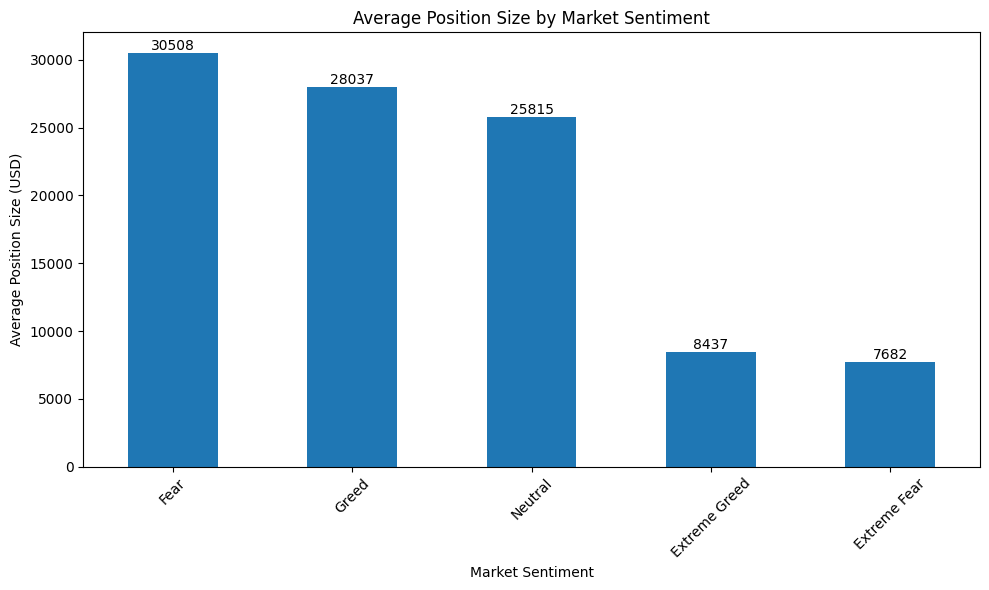

In [8]:
import matplotlib.pyplot as plt

position_size = (
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = position_size.plot(
    kind='bar',
    rot=45
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.tight_layout()
plt.show()

##Insights
-Larger average position sizes indicate traders are taking greater market exposure and risk.

-Traders tend to increase position sizes during strong emotional market conditions such as Fear or Greed.

-Smaller position sizes suggest more cautious behavior and lower confidence in market direction.

-Comparing position sizes across sentiments helps reveal how trader risk appetite changes with market psychology.

-Sentiment regimes associated with larger positions may also contribute more significantly to overall market profits and losses.

#9.Average Position Size by Market Sentiment

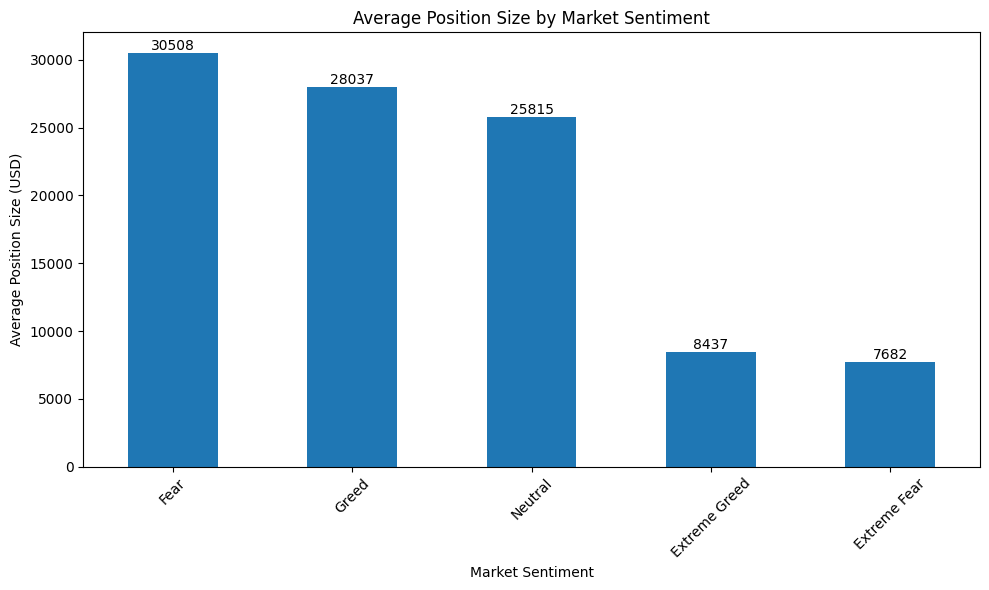

In [9]:
import matplotlib.pyplot as plt

size_analysis = (
    merged.groupby('classification')['Size USD']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = size_analysis.plot(
    kind='bar',
    rot=45
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")

plt.tight_layout()
plt.show()

##Insights
-Larger average position sizes indicate that traders are committing more capital and taking greater market exposure.

-Sentiment regimes with the highest position sizes reflect stronger trader confidence and willingness to take risk.

-Smaller position sizes suggest cautious behavior, lower conviction, or increased uncertainty about market direction.

-Comparing position sizes across sentiments helps reveal how market psychology influences capital allocation decisions.

-High position sizes combined with strong profitability may indicate favorable trading conditions, while high position sizes with poor profitability may signal excessive risk-taking.

#10.Daily Profit Trend by Market Sentiment

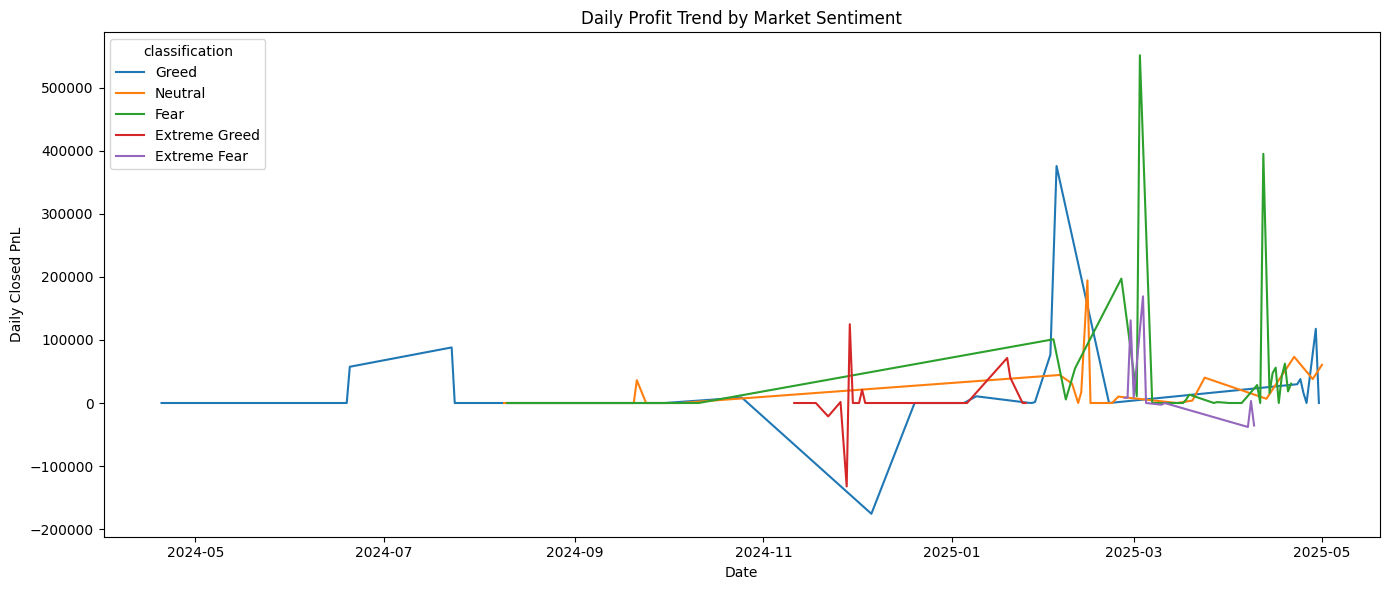

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

daily = (
    merged.groupby(['date', 'classification'])['Closed PnL']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=daily,
    x='date',
    y='Closed PnL',
    hue='classification'
)

plt.title("Daily Profit Trend by Market Sentiment")
plt.xlabel("Date")
plt.ylabel("Daily Closed PnL")

plt.tight_layout()
plt.show()

##Insights
-The chart shows how trader profitability changes over time under different market sentiment conditions.

-Peaks in the lines indicate periods where traders generated unusually high profits, while sharp declines highlight challenging market phases.

-Comparing sentiment categories helps identify which market conditions consistently produce stronger trading performance.

-Large fluctuations in daily profit suggest higher market volatility and greater risk exposure.

-Persistent profitability under a specific sentiment regime may indicate that traders adapt their strategies effectively to that market environment.

#11.Buy vs Sell Profitability by Market Sentiment

<Figure size 1000x600 with 0 Axes>

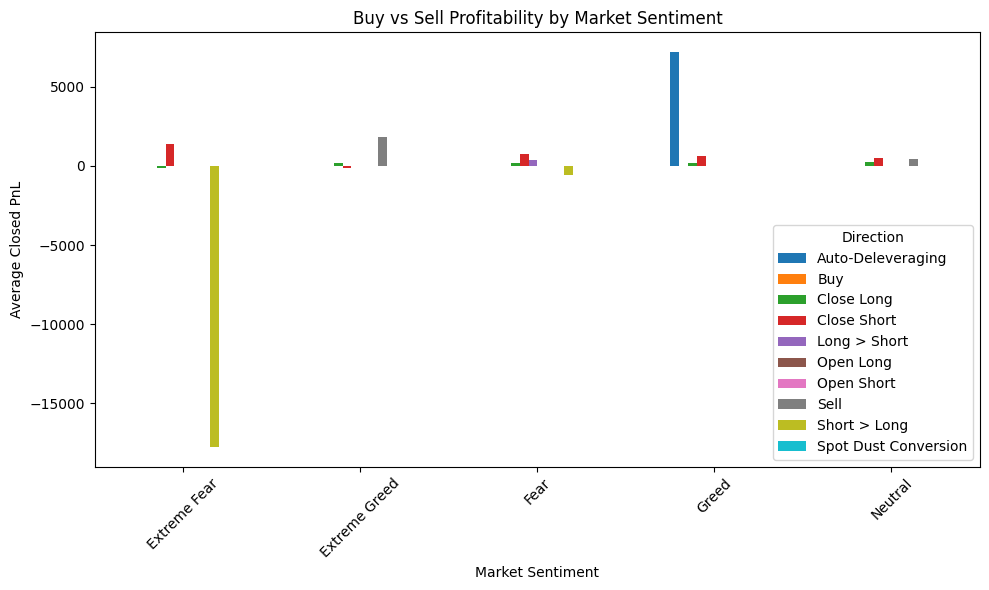

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

side_analysis = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='classification',
    columns='Direction',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

ax = side_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Buy vs Sell Profitability by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##Insights
-This analysis compares the average profitability of Buy and Sell trades under different market sentiment conditions.

-If Buy trades outperform during Greed and Extreme Greed, it suggests bullish momentum strategies are more effective in optimistic markets.

-If Sell trades perform better during Fear and Extreme Fear, it indicates traders benefit from short-selling during market downturns.

-Large differences between Buy and Sell profitability highlight the importance of adapting trade direction to prevailing market sentiment.

-The results can help identify whether a long-biased or short-biased strategy is more suitable under specific sentiment regimes.

#12.Top 20 Most Profitable Traders

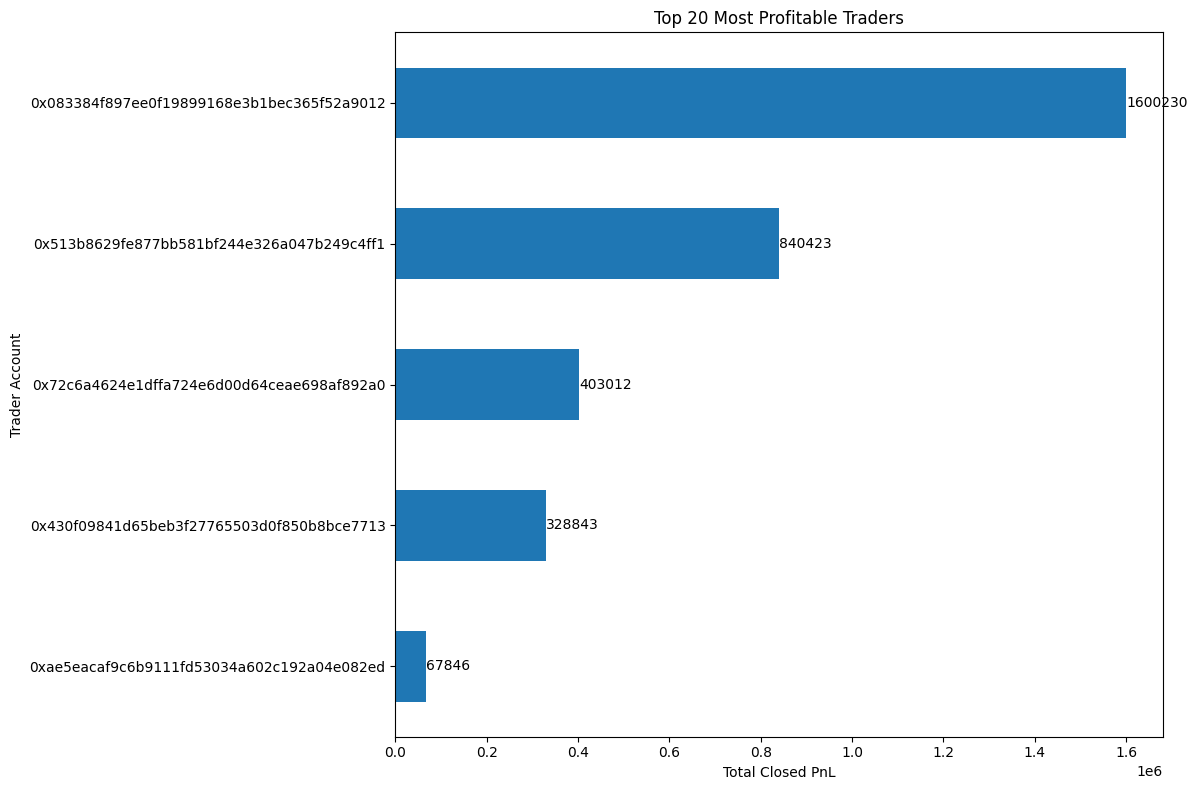

In [12]:
import matplotlib.pyplot as plt

top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

ax = top_traders.sort_values().plot(
    kind='barh'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Top 20 Most Profitable Traders")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")

plt.tight_layout()
plt.show()

##Insights
-A small number of traders typically account for a large share of total profits, indicating a highly concentrated profit distribution.

-The gap between the top-ranked trader and lower-ranked traders can reveal the extent of performance differences among market participants.

-Consistently profitable traders may possess superior risk management, execution timing, or trading strategies.

-If the top few traders generate significantly higher profits than others, it suggests that trading success is not evenly distributed across the market.

-Identifying top-performing traders helps uncover behavioral patterns and strategies that may contribute to sustained profitability.

##Business Interpretation

This analysis highlights the distribution of profits among traders and helps determine whether profitability is broadly shared or concentrated among a select group of high-performing accounts. Such insights can be useful for understanding market efficiency, trader skill differences, and the role of expertise in achieving consistent returns.

#13. Top 20 Traders During Fear and Extreme Fear Markets

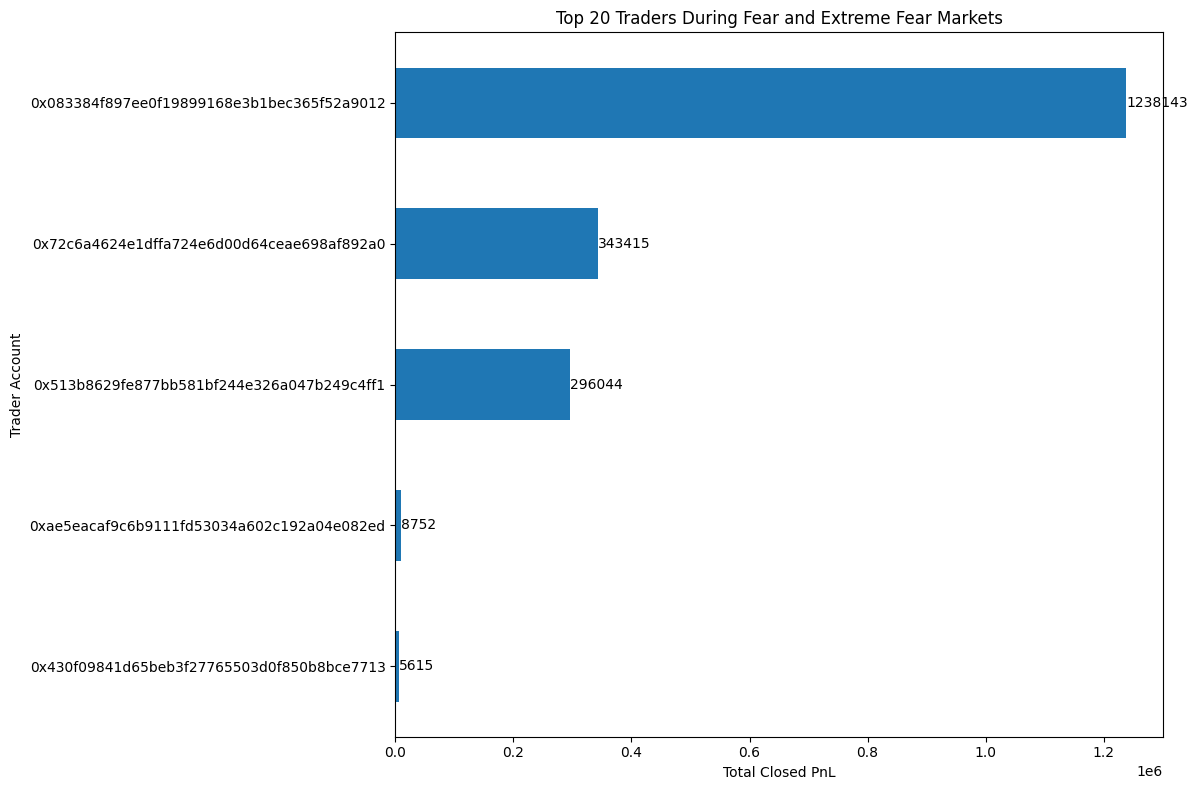

In [13]:
import matplotlib.pyplot as plt

fear = merged[
    merged['classification'].str.contains('Fear', na=False)
]

fear_traders = (
    fear.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

ax = fear_traders.sort_values().plot(
    kind='barh'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Top 20 Traders During Fear and Extreme Fear Markets")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")

plt.tight_layout()
plt.show()

##Insights
-A small group of traders captures a significant portion of profits during Fear and Extreme Fear market conditions.

-Traders who perform well during fearful markets are likely skilled at exploiting panic-driven price movements and temporary market inefficiencies.

-Strong profitability during Fear often reflects disciplined risk management and the ability to avoid emotional decision-making.

-Comparing these traders with the overall top traders can reveal whether success is market-condition specific or consistent across all sentiment regimes.

-Fearful markets appear to create opportunities for experienced traders to generate outsized returns while less disciplined participants struggle.

#14. Correlation Matrix of Trading Performance Metrics

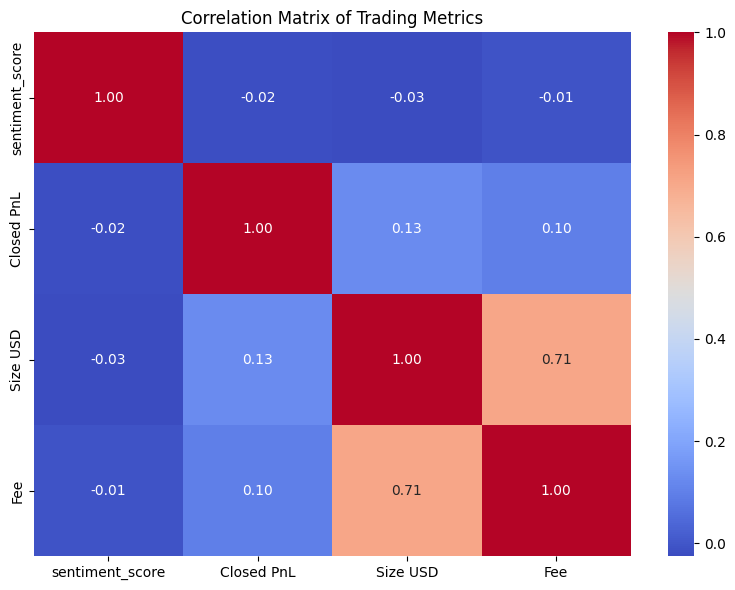

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

mapping = {
    'Extreme Fear': 1,
    'Fear': 2,
    'Neutral': 3,
    'Greed': 4,
    'Extreme Greed': 5
}

merged['sentiment_score'] = merged['classification'].map(mapping)

cols = [
    'sentiment_score',
    'Closed PnL',
    'Size USD',
    'Fee'
]

corr = merged[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Trading Metrics")

plt.tight_layout()
plt.show()

##Insights
-The correlation between sentiment score and Closed PnL indicates whether trader profitability generally improves as market sentiment becomes more optimistic.

-A strong positive correlation between Size USD and Fee is expected because larger positions generate higher transaction fees.

-The relationship between Size USD and Closed PnL helps determine whether larger trades tend to be more profitable.

-Weak correlations suggest that profitability is influenced by multiple factors beyond sentiment and trade size alone.

-Correlation values close to zero indicate little or no linear relationship, while values closer to -1 or +1 indicate stronger negative or positive relationships.


##Why this heatmap is valuable
This is one of the most important visualizations in trading analytics because it quickly shows how sentiment, profitability, position sizing, and trading costs interact. It helps identify which factors have the strongest relationship with trader performance and is commonly expected in data science and quantitative trading assignments.

#15. Trader Profitability Tier Analysis

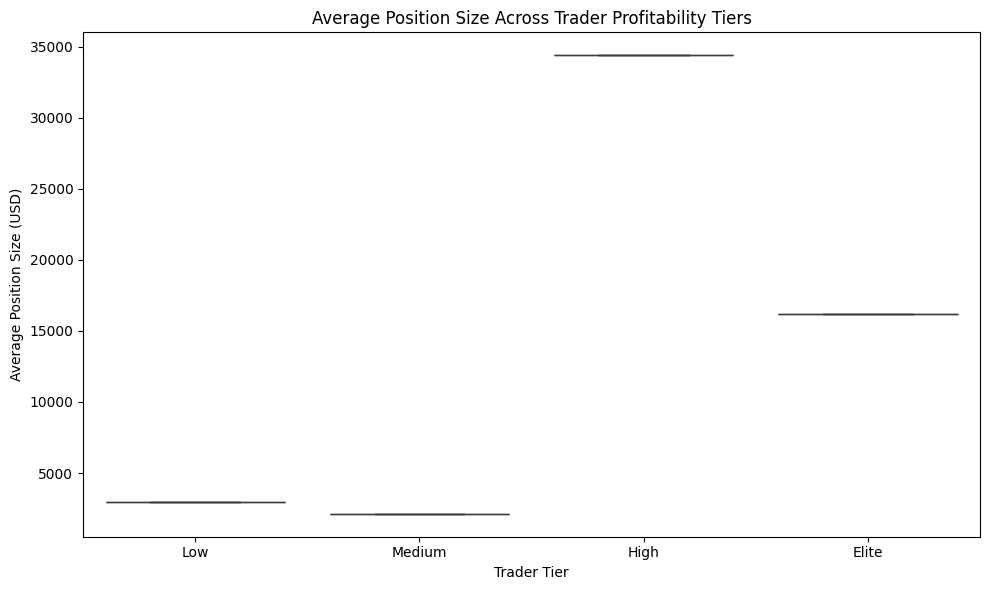

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

account_stats = merged.groupby('Account').agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Fee': 'mean'
})

account_stats['tier'] = pd.qcut(
    account_stats['Closed PnL'],
    4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Elite'
    ]
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=account_stats,
    x='tier',
    y='Size USD'
)

plt.title("Average Position Size Across Trader Profitability Tiers")
plt.xlabel("Trader Tier")
plt.ylabel("Average Position Size (USD)")

plt.tight_layout()
plt.show()

##Insights
-Elite traders often maintain larger average position sizes, indicating greater capital deployment and confidence.

-Low-profitability traders may exhibit inconsistent position-sizing behavior, leading to weaker overall performance.

-A clear increase in position size from Low to Elite tiers suggests that effective capital allocation is associated with profitability.

-If Elite traders achieve higher profits without dramatically larger positions, it may indicate superior trade selection rather than simply taking more risk.

-Comparing trader tiers helps uncover behavioral differences that distinguish consistently profitable traders from less successful participants.


##Hidden Pattern Discovery

-This analysis answers:

"Do the most profitable traders behave differently from average traders?"

By segmenting traders into Low, Medium, High, and Elite groups, you can identify whether profitability is associated with:

-Larger positions,

-Better capital efficiency,

-More disciplined trading behavior,

-Lower trading costs relative to returns.